<p align="left">
  <a href="https://colab.research.google.com/github/wgomezf/analisis_datos/blob/main/01_Clasificación_Bayesiana/Caso_3.ipynb" target="_parent">
    <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab" width="200">
  </a>
</p>


In [50]:
#################################################
# Autor: Wilfrido Gómez Flores (Cinvestav)      #
# E-mail: wgomez@cinvestav.mx                   #
# Curso:   Análisis de datos                    #
# Tópico:  Clasificador Bayesiano caso general  #
#################################################

Carga bibliotecas necesarias

In [51]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

Carga el conjunto de datos Iris con 3 clases, 150 muestras y 4 variables

In [52]:
iris = load_iris()
df = pd.DataFrame(data=iris.data)
X = df.to_numpy() # Características
df = pd.DataFrame(data=iris.target)
Y = df.to_numpy() # Etiquetas de clase: 1,2 3
d = X.shape[1] # Número de variables
c = np.unique(Y).size # Número de clases

Divide el conjunto de datos en 80\% para entrenamiento y 20\% para prueba

In [53]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42, stratify=Y)

Normaliza el conjunto de datos con z-score:  $z = \frac{x-\mu}{\sigma}$

In [54]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train) # Normaliza el conjunto de entrenamiento
X_test = scaler.transform(X_test) # Normaliza el conjunto de prueba usando los estadísticos del conjunto de entrenamiento

Entrenamiento del clasificador Bayesiano general: calcular la matriz del término cuadrático $W_i$, el vector del término lineal $w_i$ y el valor constante $w_{0i}$

In [55]:
W = np.zeros((c, d, d)) # Arreglo para guardar las matrices del término cuadrático
w = np.zeros((c, d)) # Arreglo para guardar los vectores del término lineal
w0 = np.zeros(c) # Arreglo para guardar el valor constante
n = X_train.shape[0] # Número de muestras de entrenamiento
for i in range(c): # Para cada clase
    wi = (Y_train == i).flatten() # Identifica a las muestras de la i-ésima clase
    Xi = X_train[wi, :]
    mu = np.mean(Xi, axis=0) # Calcula el vector de medias
    Sigma = np.cov(Xi, rowvar=False) # Calcula la matriz de covarianza
    iSigma = np.linalg.pinv(Sigma) # Inversa de la matriz de covarianza
    p = np.sum(wi) / n # Probabilidad a priori de la i-ésima clase
    W[i, :, :] = -0.5 * iSigma # Matriz del término cuadrático
    w[i, :] = iSigma @ mu.T # Vector del término lineal
    w0[i] = -0.5 * (mu @ iSigma @ mu.T) - 0.5 * np.log(np.linalg.det(Sigma)) + np.log(p) # Valor constante


Calcula la función discriminante cuadrática de la i-ésima clase en cada muestra de prueba:
\begin{equation}
{g_i}(\mathbf{x}) = {\mathbf{x}}{{W}_i}\mathbf{x}^T + \mathbf{w}_i \mathbf{x}^T + {w_{0i}},
\end{equation}

In [56]:
bayfun = lambda x, W, w, w0: (x @ W @ x.T) + (w @ x.T) + w0 # Función discriminante cuadrática
n = X_test.shape[0] # Número de muestras de prueba
D = np.zeros((n, c)) # Arreglo para guardar los valores de la función discriminante
for i in range(n):
    for j in range(c):
        D[i, j] = bayfun(X_test[i, :], W[j, :, :], w[j, :], w0[j]) # Calcula la función discriminante

La clase predicha es la que obtiene el valor más grande en la función discriminante:
\begin{equation}
\text{Decidir}\;\; \omega_i\;\;\text{si}\;\; g_i(\mathbf{x}) > g_j(\mathbf{x}) \;\;\text{para todo}\;\; i \neq j
\end{equation}

In [57]:
Y_pred = np.argmax(D, axis=1)
Y_pred = Y_pred.reshape(-1, 1) # Asegurar vector columna

Visualiza matriz de confusión

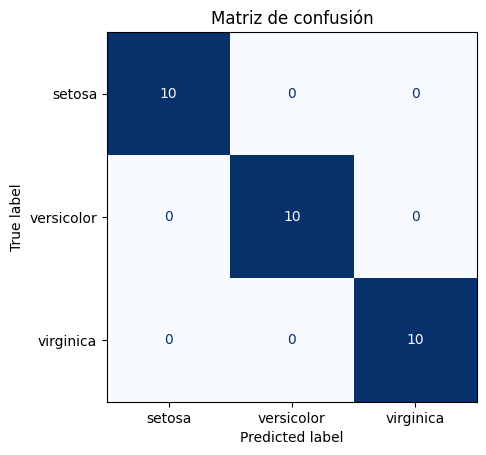

Exactitud: 1.000


In [58]:
cm = confusion_matrix(Y_test, Y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=iris.target_names)
disp.plot(colorbar=False, cmap='Blues')
plt.title('Matriz de confusión')
plt.show()
ACC = np.mean(Y_pred == Y_test)
print(f"Exactitud: {ACC:.3f}")